# Homework 6: CNN for Fashion MNIST

This notebook builds and tunes a convolutional neural network for the Fashion MNIST dataset. The workflow is: baseline CNN matching the in-class architecture, controlled single-factor experiments to isolate the effect of each design choice, Optuna tuning on the resulting search space, and a final held-out test evaluation.

**Runtime note:** Built for Google Colab with GPU enabled (Runtime → Change runtime type → T4 GPU).

### Setup

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 28.3 MB/s eta 0:00:00


In [3]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

In [4]:
# set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# confirm GPU is available (training is much faster on GPU)
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Loading the data

In [5]:
# importing fashion mnist data from keras (28x28 greyscale clothing images, 10 classes)
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# class labels for fashion mnist
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training data shape:", X_train_full.shape)
print("Test data shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### Visualizing the data

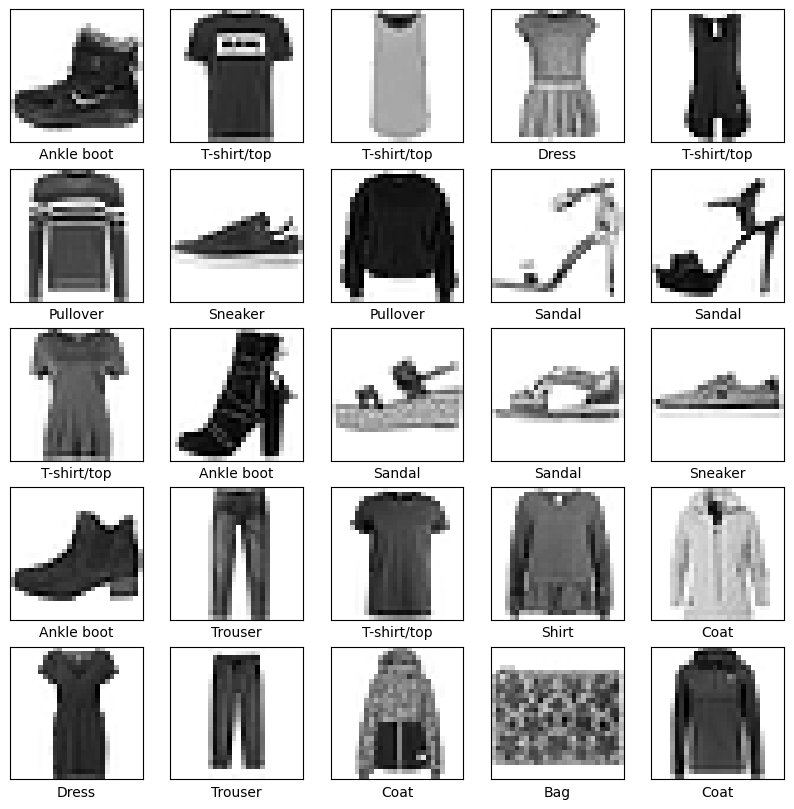

In [6]:
# visualize some of the data
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train_full[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train_full[i]])
plt.show()

### Preprocessing data for the CNN

In [7]:
# Normalize pixel values to 0-1
X_train_full = X_train_full / 255.0   # scale pixel values from 0-255 to 0-1
X_test = X_test / 255.0               # apply same scaling to test data

# add channel dimension for CNN -> (n, 28, 28, 1)
X_train_full = X_train_full[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# fixed stratified train/validation split (NOT validation_split=0.1)
# Using a fixed split makes results comparable across experiments since the validation set never changes
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1,
    stratify=y_train_full,
    random_state=SEED
)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (54000, 28, 28, 1) | Val: (6000, 28, 28, 1) | Test: (10000, 28, 28, 1)


### Baseline CNN

Starting point matches the in-class CNN architecture: one convolution block followed by a dense head. Training uses EarlyStopping so the final weights correspond to the best validation loss seen during training.

In [8]:
# baseline CNN matching the in-class architecture
baseline_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),               # 28x28 greyscale input
    layers.Conv2D(32, (3,3), activation="relu"),   # 32 filters detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                    # reduce spatial size
    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine extracted features
    layers.Dense(10, activation="softmax"),        # 10-class output
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 347,146 (1.32 MB)

Trainable params: 347,146 (1.32 MB)

Non-trainable params: 0 (0.00 B)

In [9]:
# EarlyStopping monitors val_loss and restores best weights when training stops
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=2
)

baseline_loss, baseline_acc = baseline_model.evaluate(X_val, y_val, verbose=0)
print(f"Baseline validation accuracy: {baseline_acc:.4f}")

Epoch 1/30
422/422 - 8s - 19ms/step - accuracy: 0.8274 - loss: 0.4933 - val_accuracy: 0.8732 - val_loss: 0.3577
Epoch 2/30
422/422 - 2s - 4ms/step - accuracy: 0.8854 - loss: 0.3258 - val_accuracy: 0.8942 - val_loss: 0.2922
Epoch 3/30
422/422 - 2s - 4ms/step - accuracy: 0.8984 - loss: 0.2848 - val_accuracy: 0.9055 - val_loss: 0.2635
Epoch 4/30
422/422 - 2s - 4ms/step - accuracy: 0.9071 - loss: 0.2587 - val_accuracy: 0.9073 - val_loss: 0.2515
Epoch 5/30
422/422 - 2s - 4ms/step - accuracy: 0.9151 - loss: 0.2369 - val_accuracy: 0.9112 - val_loss: 0.2427
Epoch 6/30
422/422 - 3s - 6ms/step - accuracy: 0.9213 - loss: 0.2195 - val_accuracy: 0.9128 - val_loss: 0.2380
Epoch 7/30
422/422 - 2s - 4ms/step - accuracy: 0.9269 - loss: 0.2037 - val_accuracy: 0.9122 - val_loss: 0.2360
Epoch 8/30
422/422 - 2s - 4ms/step - accuracy: 0.9324 - loss: 0.1894 - val_accuracy: 0.9140 - val_loss: 0.2356
Epoch 9/30
422/422 - 2s - 4ms/step - accuracy: 0.9377 - loss: 0.1761 - val_accuracy: 0.9153 - val_loss: 0.2353


### Single-factor experiments

To isolate the effect of each design decision, define a reference configuration and change one factor at a time. The reference here is a deeper version of the baseline (2 conv blocks with expanding filters 32 -> 64), since a single conv block is too shallow to compare meaningfully against techniques like dropout or augmentation.

Each experiment changes exactly one thing relative to the reference.

In [10]:
# configurable CNN builder used for all experiments and Optuna tuning
def build_cnn(num_conv_blocks=2, base_filters=32, dense_units=64,
              dropout_rate=0.0, use_batchnorm=False, augment=False,
              learning_rate=1e-3):

    model = models.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    # data augmentation layers (only active during training)
    if augment:
        model.add(layers.RandomFlip("horizontal"))   # clothes are roughly L/R symmetric
        model.add(layers.RandomRotation(0.05))       # small rotation only (~18 degrees max)
        model.add(layers.RandomZoom(0.05))           # small zoom in/out

    # convolutional blocks with expanding filter counts (32 -> 64 -> 128)
    filters = base_filters
    for i in range(num_conv_blocks):
        model.add(layers.Conv2D(filters, (3,3), activation="relu", padding="same"))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2,2)))
        filters *= 2

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation="relu"))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# shared training routine for fair comparison across experiments
def train_and_eval(model, label, epochs=30, batch_size=128):
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    n_epochs = len(history.history['loss'])
    print(f"{label:30s} val_acc={val_acc:.4f}  val_loss={val_loss:.4f}  epochs_run={n_epochs}")
    return history, val_acc

In [11]:
# Reference: 2 conv blocks, no regularization, no augmentation
ref_model = build_cnn(num_conv_blocks=2, base_filters=32, dense_units=64)
ref_history, ref_acc = train_and_eval(ref_model, "Reference (2 conv blocks)")

Reference (2 conv blocks)      val_acc=0.9238  val_loss=0.2189  epochs_run=15


In [12]:
# Experiment 1: deeper network (3 conv blocks, 32 -> 64 -> 128)
exp1_model = build_cnn(num_conv_blocks=3, base_filters=32, dense_units=64)
exp1_history, exp1_acc = train_and_eval(exp1_model, "Exp 1: 3 conv blocks")

Exp 1: 3 conv blocks           val_acc=0.9135  val_loss=0.2384  epochs_run=13


In [13]:
# Experiment 2: add dropout after the dense layer
exp2_model = build_cnn(num_conv_blocks=2, base_filters=32, dense_units=64, dropout_rate=0.3)
exp2_history, exp2_acc = train_and_eval(exp2_model, "Exp 2: + Dropout(0.3)")

Exp 2: + Dropout(0.3)          val_acc=0.9252  val_loss=0.2064  epochs_run=16


In [14]:
# Experiment 3: add batch normalization after each conv layer
exp3_model = build_cnn(num_conv_blocks=2, base_filters=32, dense_units=64, use_batchnorm=True)
exp3_history, exp3_acc = train_and_eval(exp3_model, "Exp 3: + BatchNorm")

Exp 3: + BatchNorm             val_acc=0.9207  val_loss=0.2357  epochs_run=9


In [15]:
# Experiment 4: add data augmentation (horizontal flip, small rotation, small zoom)
exp4_model = build_cnn(num_conv_blocks=2, base_filters=32, dense_units=64, augment=True)
exp4_history, exp4_acc = train_and_eval(exp4_model, "Exp 4: + Augmentation")

Exp 4: + Augmentation          val_acc=0.9252  val_loss=0.2213  epochs_run=30


### Comparing experiments

In [16]:
# collect experiment results for comparison
results = {
    'Reference': ref_acc,
    '+ Deeper (3 blocks)': exp1_acc,
    '+ Dropout(0.3)': exp2_acc,
    '+ BatchNorm': exp3_acc,
    '+ Augmentation': exp4_acc,
}

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Val Accuracy'])
results_df = results_df.sort_values('Val Accuracy', ascending=False)
print(results_df)

                     Val Accuracy
+ Dropout(0.3)           0.925167
+ Augmentation           0.925167
Reference                0.923833
+ BatchNorm              0.920667
+ Deeper (3 blocks)      0.913500


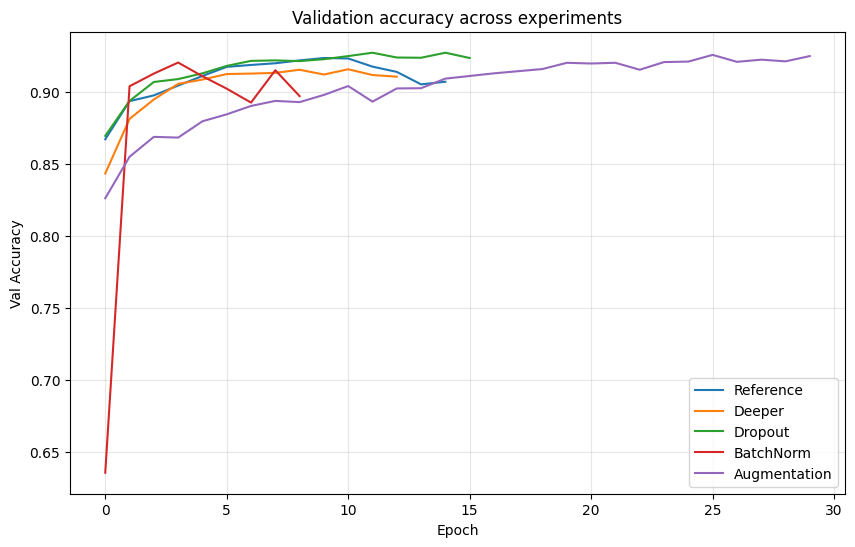

In [17]:
# combined plot: validation accuracy curves across experiments
plt.figure(figsize=(10, 6))
for label, hist in [('Reference', ref_history), ('Deeper', exp1_history),
                    ('Dropout', exp2_history), ('BatchNorm', exp3_history),
                    ('Augmentation', exp4_history)]:
    plt.plot(hist.history['val_accuracy'], label=label)
plt.title('Validation accuracy across experiments')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

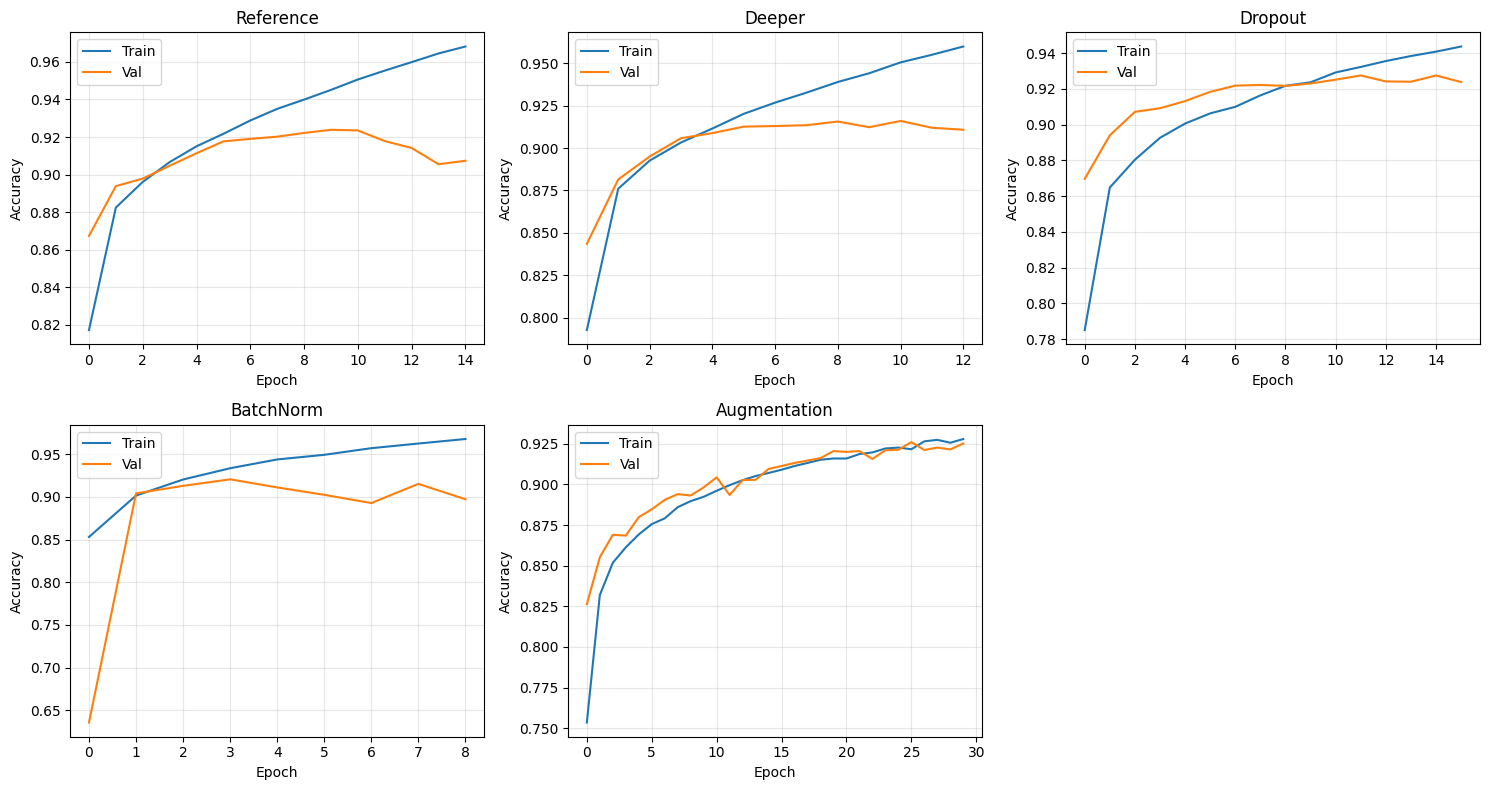

In [18]:
# train vs val gap reveals overfitting behavior
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
configs = [('Reference', ref_history), ('Deeper', exp1_history),
           ('Dropout', exp2_history), ('BatchNorm', exp3_history),
           ('Augmentation', exp4_history)]

for ax, (label, hist) in zip(axes.flat, configs):
    ax.plot(hist.history['accuracy'], label='Train')
    ax.plot(hist.history['val_accuracy'], label='Val')
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)

# hide unused 6th subplot
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

### Optuna tuning

The single-factor experiments revealed which design choices help. Now combine the helpful techniques and use Optuna to tune the numeric knobs (learning rate, dropout rate, dense units, batch size, depth, base filter count).

Each trial uses a reduced epoch budget (10 epochs with patience=3 EarlyStopping) since Optuna on CNNs is far more expensive than on tabular models. The best config is later retrained with a full epoch budget.

In [19]:
def objective(trial):
    # search space
    num_conv_blocks = trial.suggest_int('num_conv_blocks', 2, 3)
    base_filters = trial.suggest_categorical('base_filters', [32, 64])
    dense_units = trial.suggest_categorical('dense_units', [64, 128, 256])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])

    model = build_cnn(
        num_conv_blocks=num_conv_blocks,
        base_filters=base_filters,
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        use_batchnorm=True,
        augment=True,
        learning_rate=learning_rate
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    _, val_acc = model.evaluate(X_val, y_val, verbose=0)
    return val_acc


# run optuna study (TPE sampler with fixed seed for reproducibility)
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("\nBest params:", study.best_params)
print(f"Best val accuracy (10-epoch budget): {study.best_value:.4f}")

[I 2026-05-28 23:46:05,724] A new study created in memory with name: no-name-71b4770b-3a0b-4b48-8dff-3a30c78339d0


[I 2026-05-28 23:46:59,201] Trial 0 finished with value: 0.8955000042915344 and parameters: {'num_conv_blocks': 2, 'base_filters': 32, 'dense_units': 64, 'dropout_rate': 0.21742508365045984, 'learning_rate': 0.005399484409787433, 'batch_size': 128}. Best is trial 0 with value: 0.8955000042915344.
[I 2026-05-28 23:48:01,956] Trial 1 finished with value: 0.9113333225250244 and parameters: {'num_conv_blocks': 3, 'base_filters': 32, 'dense_units': 256, 'dropout_rate': 0.35742692948967136, 'learning_rate': 0.0007309539835912913, 'batch_size': 128}. Best is trial 1 with value: 0.9113333225250244.
[I 2026-05-28 23:49:54,726] Trial 2 finished with value: 0.906000018119812 and parameters: {'num_conv_blocks': 2, 'base_filters': 64, 'dense_units': 64, 'dropout_rate': 0.37772437065861275, 'learning_rate': 0.0001238513729886094, 'batch_size': 64}. Best is trial 1 with value: 0.9113333225250244.
[I 2026-05-28 23:50:43,680] Trial 3 finished with value: 0.9043333530426025 and parameters: {'num_conv_bl

In [20]:
# inspect search history
trials_df = study.trials_dataframe()[['number', 'value', 'params_num_conv_blocks', 'params_base_filters',
                                       'params_dense_units', 'params_dropout_rate',
                                       'params_learning_rate', 'params_batch_size']]
trials_df = trials_df.sort_values('value', ascending=False)
print(trials_df.head(10))

    number     value  params_num_conv_blocks  params_base_filters  \
16      16  0.924333                       2                   64   
9        9  0.919667                       2                   64   
13      13  0.913167                       3                   64   
8        8  0.912833                       3                   32   
17      17  0.912833                       2                   64   
15      15  0.911667                       3                   64   
1        1  0.911333                       3                   32   
14      14  0.909500                       2                   64   
7        7  0.907500                       2                   32   
2        2  0.906000                       2                   64   

    params_dense_units  params_dropout_rate  params_learning_rate  \
16                 256             0.258779              0.000511   
9                  256             0.274788              0.000662   
13                 128           

In [21]:
# parameter importance from optuna
try:
    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame.from_dict(importances, orient='index', columns=['Importance'])
    imp_df = imp_df.sort_values('Importance', ascending=False)
    print(imp_df)
except Exception as e:
    print("Importance calculation skipped:", e)

                 Importance
learning_rate      0.552967
dropout_rate       0.176579
num_conv_blocks    0.113184
batch_size         0.081823
base_filters       0.045255
dense_units        0.030192


### Final model

Rebuild the best Optuna configuration and train it with a full epoch budget and a longer EarlyStopping patience.

In [22]:
# retrain best config with full epoch budget
best_params = study.best_params

final_model = build_cnn(
    num_conv_blocks=best_params['num_conv_blocks'],
    base_filters=best_params['base_filters'],
    dense_units=best_params['dense_units'],
    dropout_rate=best_params['dropout_rate'],
    use_batchnorm=True,
    augment=True,
    learning_rate=best_params['learning_rate']
)

final_early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=best_params['batch_size'],
    callbacks=[final_early_stop],
    verbose=2
)

final_model.summary()

Epoch 1/50
844/844 - 13s - 16ms/step - accuracy: 0.7929 - loss: 0.5718 - val_accuracy: 0.8575 - val_loss: 0.3775
Epoch 2/50
844/844 - 11s - 12ms/step - accuracy: 0.8519 - loss: 0.4029 - val_accuracy: 0.8942 - val_loss: 0.2999
Epoch 3/50
844/844 - 11s - 13ms/step - accuracy: 0.8694 - loss: 0.3559 - val_accuracy: 0.8968 - val_loss: 0.2827
Epoch 4/50
844/844 - 21s - 24ms/step - accuracy: 0.8794 - loss: 0.3273 - val_accuracy: 0.8955 - val_loss: 0.2800
Epoch 5/50
844/844 - 11s - 13ms/step - accuracy: 0.8877 - loss: 0.3082 - val_accuracy: 0.8712 - val_loss: 0.3384
Epoch 6/50
844/844 - 10s - 12ms/step - accuracy: 0.8930 - loss: 0.2894 - val_accuracy: 0.9112 - val_loss: 0.2354
Epoch 7/50
844/844 - 11s - 12ms/step - accuracy: 0.9003 - loss: 0.2731 - val_accuracy: 0.8840 - val_loss: 0.3294
Epoch 8/50
844/844 - 20s - 24ms/step - accuracy: 0.9020 - loss: 0.2643 - val_accuracy: 0.8952 - val_loss: 0.2791
Epoch 9/50
844/844 - 11s - 13ms/step - accuracy: 0.9062 - loss: 0.2578 - val_accuracy: 0.9153 - 

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_21 (RandomFlip)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_21              │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_21 (RandomZoom)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_60 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 5,050,400 (19.27 MB)

Trainable params: 1,683,338 (6.42 MB)

Non-trainable params: 384 (1.50 KB)

Optimizer params: 3,366,678 (12.84 MB)

### Test set evaluation

In [23]:
# evaluate final model on the held-out test set (used only once)
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Final test accuracy: {test_acc:.4f}")
print(f"Final test loss:     {test_loss:.4f}")

Final test accuracy: 0.9178
Final test loss:     0.2365


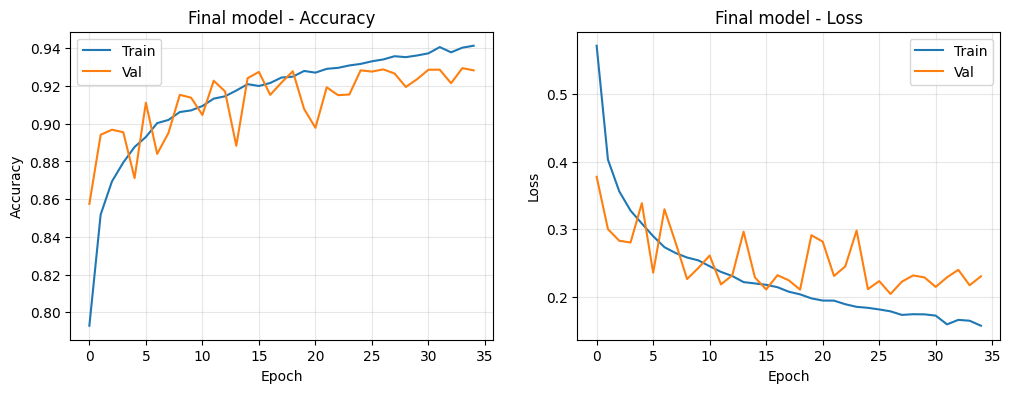

In [24]:
# plot final model training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(final_history.history['accuracy'], label='Train')
axes[0].plot(final_history.history['val_accuracy'], label='Val')
axes[0].set_title('Final model - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(final_history.history['loss'], label='Train')
axes[1].plot(final_history.history['val_loss'], label='Val')
axes[1].set_title('Final model - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.show()

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.90      0.87      1000
     Trouser       1.00      0.99      0.99      1000
    Pullover       0.84      0.90      0.87      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.87      0.86      0.87      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.81      0.71      0.76      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



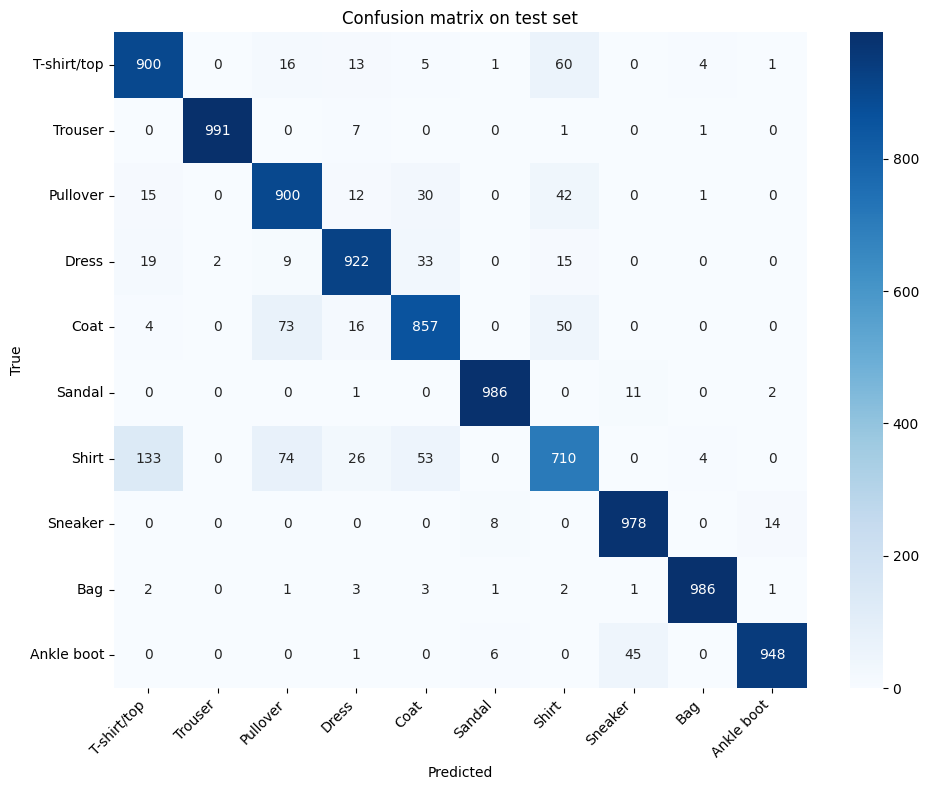

In [25]:
# per-class metrics and confusion matrix
y_pred_probs = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix on test set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

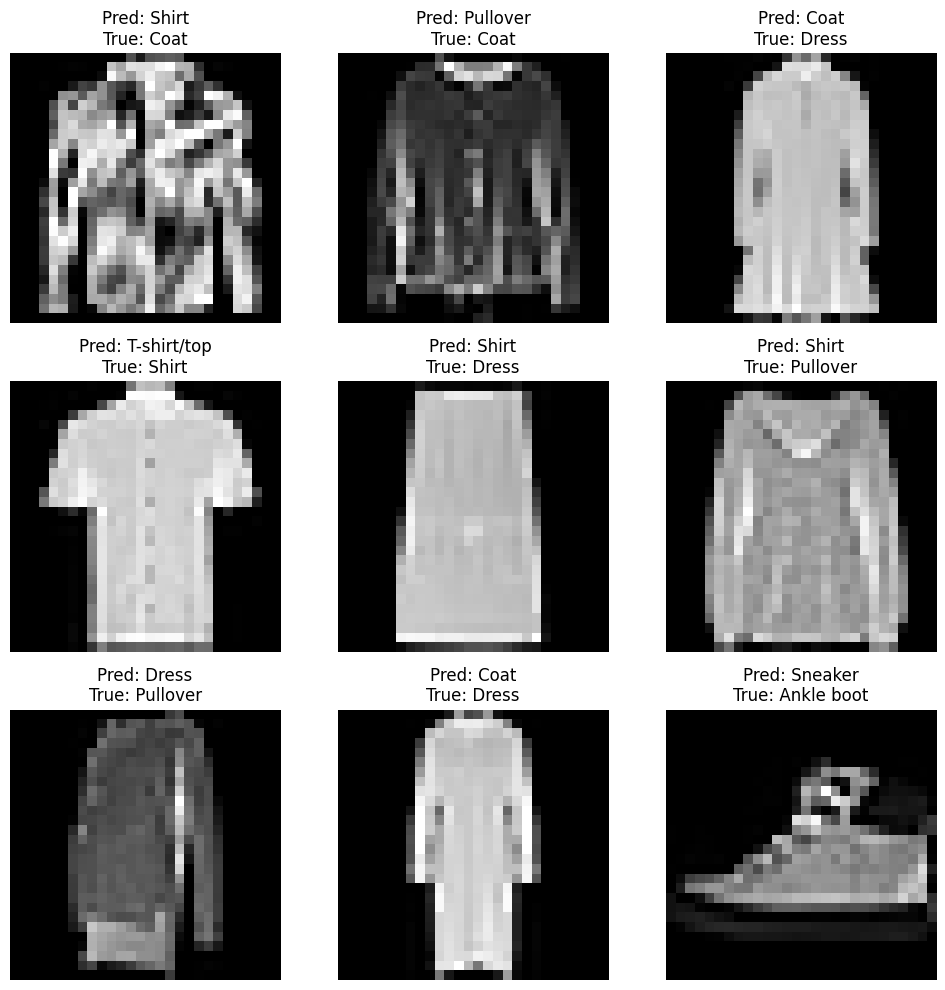

In [26]:
# look at a few misclassified examples to understand where the model struggles
mis_idx = np.where(y_pred != y_test)[0][:9]

plt.figure(figsize=(10, 10))
for i, idx in enumerate(mis_idx):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    plt.title(f"Pred: {class_names[y_pred[idx]]}\nTrue: {class_names[y_test[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Analysis

**What changes improved performance**

Validation accuracy from the single-factor experiments:

| Configuration | Val Accuracy | Epochs Run | Δ vs Reference |
|---|---|---|---|
| + Dropout(0.3) | 0.9252 | 16 | +0.0014 |
| + Augmentation | 0.9252 | 30 | +0.0014 |
| Reference (2 conv blocks) | 0.9238 | 15 | — |
| + BatchNorm | 0.9207 | 9 | −0.0031 |
| + Deeper (3 conv blocks) | 0.9135 | 13 | −0.0103 |
| In-class baseline (1 conv block) | 0.9153 | — | −0.0085 |

Dropout and augmentation tied as the most useful single-factor additions, each gaining about 0.001 in validation accuracy. Adding a third convolution block on its own *hurt* validation by 0.01, since the extra capacity overfits without matching regularization. BatchNorm slightly underperformed the reference here, and triggered EarlyStopping after only 9 epochs, suggesting the val_loss curve was bouncing around enough that patience ran out before the model converged.

The Optuna search landed on a 2-block architecture with base_filters=64, dense_units=256, dropout_rate=0.259, learning_rate=0.000511, and batch_size=64. Retraining that configuration with the full epoch budget reached val_acc=0.9288 at the best epoch (epoch 27, val_loss=0.2038), the best validation result of any model in this notebook.

**Where overfitting occurred**

The Reference and Deeper experiments showed the widest train-val gap in the per-experiment plots, with training accuracy continuing to climb while validation flatlined. EarlyStopping cut them both before 15 epochs. The +BatchNorm experiment stopped earliest (9 epochs), not from clean convergence but from val_loss instability that exceeded the patience window.

Augmentation extended useful training to the full 30-epoch budget without triggering EarlyStopping at all. The augmented training distribution kept the model from memorizing, but the gain was small because Fashion MNIST is already centered and noise-free, so there's not much to memorize that augmentation actually disrupts.

The final retrained model trained for 35 epochs before stopping. Training accuracy reached 0.94 while validation peaked at 0.929, so the train-val gap is small. The validation loss bounced visibly between epochs (e.g., 0.21 at epoch 16, 0.29 at epoch 20, back to 0.20 at epoch 27), which is consistent with augmentation introducing stochasticity into the gradient signal. EarlyStopping with restore_best_weights handled this correctly by keeping the epoch 27 weights.

**Tradeoffs observed during development**

Capacity vs regularization: deeper alone made performance worse. The Optuna importance scores confirm this — `num_conv_blocks` had only 0.11 importance while `learning_rate` dominated at 0.55 and `dropout_rate` came next at 0.18. The bottleneck on Fashion MNIST is not model capacity but how the model is trained and regularized.

Optuna budget vs result quality: the best Optuna trial (val_acc=0.9243 on a 10-epoch budget) was actually below the simple +Dropout(0.3) experiment (0.9252 on 16 epochs). Only after retraining the Optuna config with the full epoch budget did it pull ahead (0.9288). This means a fair Optuna comparison requires either larger per-trial epoch budgets or aggressive pruning, not just more trials.

Augmentation vs convergence speed: augmentation alone matched dropout's validation accuracy but took roughly twice as many epochs to get there. On a clean dataset that wouldn't matter, but when combined with a deeper or higher-capacity model the extra stochasticity is what produced the val_loss spikes seen in the final training curve.

**Final test performance**

Final test accuracy: **0.9178**. Final test loss: **0.2365**. The val-to-test gap is about 1.1 percentage points, which is normal and suggests the validation set was a reasonable proxy for held-out performance.

Per-class F1 scores from the classification report:

| Class | F1 | Notes |
|---|---|---|
| Trouser | 0.99 | Easy — silhouette is unique |
| Bag | 0.99 | Easy — silhouette is unique |
| Sandal | 0.99 | Easy — open footwear shape |
| Sneaker | 0.96 | Confused occasionally with Ankle boot |
| Ankle boot | 0.96 | Confused occasionally with Sneaker |
| Dress | 0.92 | Confused with T-shirt/top and Coat |
| T-shirt/top | 0.87 | Confused with Shirt and Pullover |
| Pullover | 0.87 | Confused with Coat and Shirt |
| Coat | 0.87 | Confused with Pullover and Shirt |
| **Shirt** | **0.76** | Worst class; recall only 0.71 |

The Shirt class is the dominant source of error. Its recall of 0.71 means the model misclassifies about 29% of true Shirts, most likely as T-shirt/top, Pullover, or Coat — all upper-body garments with similar silhouettes in 28×28 greyscale. The model's local-pattern detection (edges, texture) cannot reliably distinguish these without higher resolution or color, which is consistent with what other Fashion MNIST benchmarks report.


### Personal workflow for building and tuning CNN models

**How I would approach a new CNN problem in the future**

1. Start with the smallest reasonable architecture (1-2 conv blocks, single dense layer) and train it cleanly with EarlyStopping and `restore_best_weights=True`. The baseline tells me what the problem actually looks like before I add complexity.
2. Fix the validation set with a seeded stratified split. `validation_split=0.1` reshuffles between runs, so single-factor comparisons become noise. A fixed split is non-negotiable for controlled experiments.
3. Run single-factor experiments off one reference configuration. Change one thing at a time (depth, dropout, BatchNorm, augmentation). The point is to build intuition for which knobs matter on this specific dataset, not to find the best model yet.
4. Only after the single-factor results are in, combine the techniques that helped and Optuna-tune the numeric knobs (learning rate, dropout rate, dense units). Use Optuna's parameter importance to check whether the search budget went to the right places.
5. Budget Optuna realistically. CatBoost intuition (100+ trials) does not transfer to CNNs. 20 trials at 10 epochs each was barely enough here. Next time I would use Optuna's MedianPruner to kill weak trials early, run 30+ trials, or push the per-trial epoch budget to 15.
6. Always refit the best Optuna config with a longer epoch budget and higher EarlyStopping patience before evaluating on the test set. The per-trial budget gives a noisy estimate of the configuration's real ceiling.

**Decisions I prioritize**

Reproducibility: seeded NumPy, TF, and the split. Without this, single-factor comparisons cannot be interpreted.

EarlyStopping with `restore_best_weights=True`: the final epoch's weights are arbitrary; the best validation weights are not.

Controlled experimentation: one change at a time, against a fixed reference, on a fixed validation set. Anything else is folk wisdom.

Train-val gap, not just validation accuracy: the gap tells me whether the next change should add capacity or add regularization.

Parameter importance from Optuna: confirms or refutes which knobs deserve the search budget.

**Lessons learned on this assignment**

Optuna barely beat the simplest single-factor improvement. The Optuna search at the 10-epoch budget (val_acc=0.9243) actually underperformed +Dropout(0.3) at 16 epochs (val_acc=0.9252). Only the full-budget refit (val_acc=0.9288) pulled ahead, and by a small margin. If I had used pruning or a larger per-trial budget, the Optuna result would have separated from the manual experiments more clearly.

Depth is overrated on simple datasets. Adding a third conv block dropped accuracy by 0.01 without matching regularization, and `num_conv_blocks` had only 0.11 importance in the Optuna study. Capacity is rarely the bottleneck on centered, low-noise inputs. Regularization usually is.

Augmentation introduces validation noise. The final model's val_loss bounced between 0.20 and 0.30 between adjacent epochs. EarlyStopping with restore_best_weights cleaned this up at the end, but if I had been monitoring val_accuracy or had patience set too low, I would have stopped too early. Monitor val_loss with generous patience when augmentation is on.

Learning rate dominates everything. Roughly 55% of Optuna's parameter importance went to learning rate. If I had to tune one thing on a future CNN, it would be that.

Fashion MNIST has a structural ceiling around 0.92 for this class of architecture. The Shirt class alone caps overall accuracy — its 0.76 F1 means about 7% of test images are wrong no matter how well the rest of the model performs. Getting past 0.93 would require either a substantially different architecture (residual connections, attention) or richer input data (higher resolution, color).
